# End-to-End

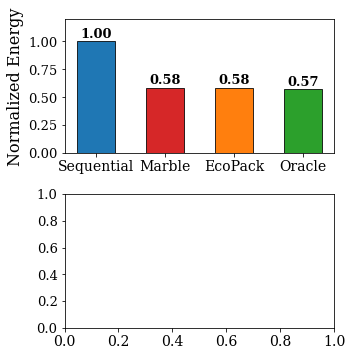

In [6]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 13,
})

policies = ['Sequential', 'Marble', 'EcoPack','Oracle']
energy_kj = [593, 346, 346, 338]
makespan_s = [393.14, 274.31, 265.40, 208.23]
edp = [e * m for e, m in zip(energy_kj, makespan_s)]

colors = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c']

# Normalize all to Sequential = 1
data = [energy_kj, edp]
ylabels = ['Normalized Energy']

normed = [[v / d[0] for v in d] for d in data]

fig, axes = plt.subplots(2, 1, figsize=(5, 5))

for ax, vals, ylabel in zip(axes, normed, ylabels):
    bars = ax.bar(policies, vals, color=colors, edgecolor='black',
                  linewidth=0.8, width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.2)

plt.tight_layout()
plt.savefig('./fig/energy_comparison.png', dpi=300)
plt.show()


# Per-job performance

In [2]:
from pathlib import Path
import re
import pandas as pd

perf_path = Path("/home/ac.zzheng/power/GPGPU/data/H100/perf_metrics.txt")
online_path = Path("/home/ac.zzheng/power/GPGPU/coSched/results/EcoPack_run.txt")

def parse_perf_max_runtime(path: Path):
    lines = path.read_text().splitlines()
    section_re = re.compile(r"^===== .*?/([^/ ]+) =====$")
    current_app = None
    rows = {}

    for raw in lines:
        line = raw.strip()
        if not line:
            continue

        m = section_re.match(line)
        if m:
            current_app = m.group(1)
            rows[current_app] = {}
            continue

        if current_app is None or line.startswith("cap=") or line.startswith("gpu_count"):
            continue

        parts = line.split()
        if len(parts) < 3:
            continue

        gpu_count = int(parts[0])
        runtime_s = float(parts[1])
        rows[current_app][gpu_count] = runtime_s

    # use the runtime at the maximum available GPU count for each app
    max_runtime = {}
    max_gpu = {}
    for app, app_rows in rows.items():
        g = max(app_rows)
        max_gpu[app] = g
        max_runtime[app] = app_rows[g]

    return max_runtime, max_gpu

def parse_online_runtime(path: Path):
    lines = path.read_text().splitlines()
    start = next(i for i, line in enumerate(lines) if line.strip() == "Online co-schedule summary:")

    runtimes = {}
    row_re = re.compile(r"^\s*(\S+).+?([0-9]+\.[0-9]+)\s*$")

    for line in lines[start + 3:]:
        s = line.strip()
        if not s or set(s) == {"-"}:
            break
        m = row_re.match(line)
        if m:
            app = m.group(1)
            runtime_s = float(m.group(2))
            runtimes[app] = runtime_s

    return runtimes

baseline_rt, baseline_gpu = parse_perf_max_runtime(perf_path)
online_rt = parse_online_runtime(online_path)

apps = sorted(set(baseline_rt) & set(online_rt))

rows = []
for app in apps:
    base = baseline_rt[app]
    online = online_rt[app]

    runtime_increase_pct = (online - base) / base * 100.0
    performance_loss_pct = (1.0 - (base / online)) * 100.0

    rows.append({
        "app": app,
        "baseline_gpu": baseline_gpu[app],
        "baseline_runtime_s": base,
        "online_runtime_s": online,
        "runtime_delta_s": online - base,
        "runtime_increase_pct": runtime_increase_pct,
        "performance_loss_pct": performance_loss_pct,
    })

df = pd.DataFrame(rows).sort_values("performance_loss_pct", ascending=False)
print(df.to_string(index=False))


                            app  baseline_gpu  baseline_runtime_s  online_runtime_s  runtime_delta_s  runtime_increase_pct  performance_loss_pct
                 simpleMultiGPU             4               10.58             18.02             7.44             70.321361             41.287458
                           bert             4               21.03             28.03             7.00             33.285782             24.973243
     streamOrderedAllocationP2P             2               17.44             22.02             4.58             26.261468             20.799273
                       resnet50             4               20.85             26.03             5.18             24.844125             19.900115
                           gpt2             4               18.79             23.03             4.24             22.565194             18.410769
                     cloverleaf             4               16.83             20.02             3.19             18.954248        

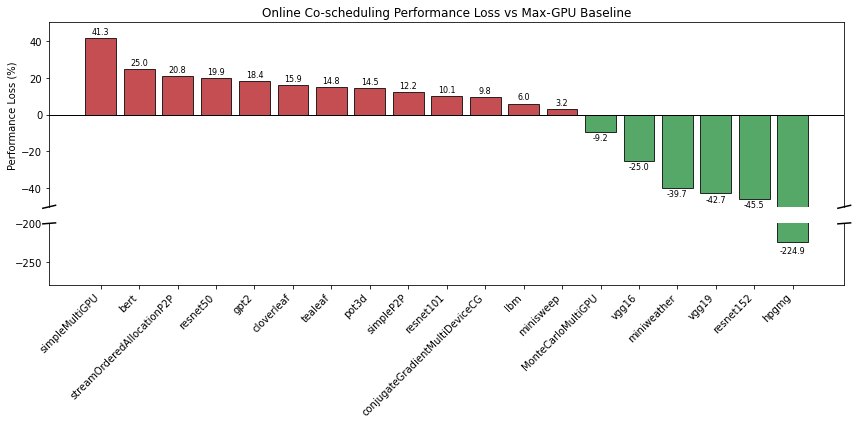

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# df already contains:
# app, performance_loss_pct

plot_df = df.sort_values("performance_loss_pct", ascending=False).reset_index(drop=True)

x = range(len(plot_df))
y = plot_df["performance_loss_pct"].values

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, figsize=(12, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# top axis: normal range including all positive values and mild negatives
ax_top.set_ylim(-50, 50)

# bottom axis: only extreme negative outlier region
ax_bottom.set_ylim(-280, -200)

colors = ["#C44E52" if v > 0 else "#55A868" for v in y]
bar_kwargs = dict(edgecolor="black", linewidth=0.8)

ax_top.bar(x, y, color=colors, **bar_kwargs)
ax_bottom.bar(x, y, color=colors, **bar_kwargs)

# broken axis styling
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False)
ax_bottom.xaxis.tick_bottom()

d = 0.008
kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_top.axhline(0, color="black", linewidth=1)

ax_bottom.set_xticks(list(x))
ax_bottom.set_xticklabels(plot_df["app"], rotation=45, ha="right")
ax_top.set_ylabel("Performance Loss (%)")
ax_top.set_title("Online Co-scheduling Performance Loss vs Max-GPU Baseline")

for i, v in enumerate(y):
    if v < -200:
        ax = ax_bottom
        ax.text(i, v - 5, f"{v:.1f}", ha="center", va="top", fontsize=8)
    else:
        va = "bottom" if v >= 0 else "top"
        offset = 1.0 if v >= 0 else -1.0
        ax_top.text(i, v + offset, f"{v:.1f}", ha="center", va=va, fontsize=8)

plt.tight_layout()
plt.show()
